### Student Name: Mohammed Laalahmi
### Student Num  : 041178810

## 🧠 Business Objective

The goal of this project is to develop a **Linear Regression model** that can accurately predict the **price of a house** based on several features such as:
- Size of the house (`squareMeters`)
- Number of rooms
- Presence of amenities (yard, pool, garage, etc.)
- Location information (cityCode, cityPartRange)
- Year of construction and other property details.

This model will help stakeholders such as **real estate agencies or buyers** estimate the market value of a house given its characteristics.


## 📊 Data Understanding

The dataset used in this project is `housing.csv`.  
Each row represents a house listing with its attributes and corresponding price.  

### Features:
| Column Name | Description |
|--------------|-------------|
| squareMeters | Total area of the house in square meters |
| numberOfRooms | Number of rooms in the house |
| hasYard | Whether the house has a yard (Yes/No) |
| hasPool | Whether the house has a swimming pool (Yes/No) |
| floors | Number of floors |
| cityCode | Numeric code representing the city |
| cityPartRange | City subdivision or area range |
| numPrevOwners | Number of previous owners |
| made | Year the house was built |
| isNewBuilt | Whether the house is newly built (Yes/No) |
| hasStormProtector | Whether the house has storm protection (Yes/No) |
| basement | Basement size or feature |
| attic | Attic size or feature |
| garage | Garage size or feature |
| hasStorageRoom | Whether the house has a storage room (Yes/No) |
| hasGuestRoom | Number of guest rooms |
| price | **Target variable** — Price of the house |

The dataset appears to include both **numerical** and **categorical** columns, which means we will need to perform **data cleaning** and **feature engineering** before training our regression model.


In [98]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [99]:
# Load dataset
df = pd.read_csv(r"C:\Users\pc\Downloads\housing.csv")

In [100]:
# Display first 5 rows
df.head(5)

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,75523,3,No,Yes,63,9373,3,8,2005,No,Yes,4313,9005,956,0,7,7559081.5
1,80771,39,Yes,Yes,98,39381,8,6,2015,Yes,No,3653,2436,128,1,2,8085989.5
2,55712,58,No,Yes,19,34457,6,8,2021,No,No,2937,8852,135,1,9,5574642.1
3,32316,47,No,No,6,27939,10,4,2012,No,Yes,659,7141,359,0,3,3232561.2
4,70429,19,Yes,Yes,90,38045,3,7,1990,Yes,No,8435,2429,292,1,4,7055052.0


## 🧩 Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand its structure, identify data types, detect missing values, and gain basic insights about the features and the target variable (`price`).


In [101]:
# Number of rows and columns
print("Number of instances:", df.shape[0])
print("Number of attributes:", df.shape[1])

Number of instances: 10000
Number of attributes: 17


In [102]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   squareMeters       10000 non-null  int64  
 1   numberOfRooms      10000 non-null  int64  
 2   hasYard            10000 non-null  object 
 3   hasPool            10000 non-null  object 
 4   floors             10000 non-null  int64  
 5   cityCode           10000 non-null  int64  
 6   cityPartRange      10000 non-null  int64  
 7   numPrevOwners      10000 non-null  int64  
 8   made               10000 non-null  int64  
 9   isNewBuilt         10000 non-null  object 
 10  hasStormProtector  10000 non-null  object 
 11  basement           10000 non-null  int64  
 12  attic              10000 non-null  int64  
 13  garage             10000 non-null  int64  
 14  hasStorageRoom     10000 non-null  int64  
 15  hasGuestRoom       10000 non-null  int64  
 16  price              1000

### Observations:
- The dataset contains `10000` instances (rows) and `17` attributes (columns).
- Some columns such as `hasYard`, `hasPool`, `hasStormProtector` and `isNewBuilt` are categorical but stored as strings.
- All other columns appear to be numerical.


In [103]:
# Summary statistics for numerical columns
df.describe()

,squareMeters,numberOfRooms,floors,cityCode,cityPartRange,numPrevOwners,made,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.00000,10000.000000,10000.00000,1.000000e+04
mean,49870.13120,50.358400,50.276300,50225.486100,5.510100,5.521700,2005.48850,5033.103900,5028.01060,553.12120,0.503000,4.99460,4.993448e+06
std,28774.37535,28.816696,28.889171,29006.675799,2.872024,2.856667,9.30809,2876.729545,2894.33221,262.05017,0.500016,3.17641,2.877424e+06
min,89.00000,1.000000,1.000000,3.000000,1.000000,1.000000,1990.00000,0.000000,1.00000,100.00000,0.000000,0.00000,1.031350e+04
25%,25098.50000,25.000000,25.000000,24693.750000,3.000000,3.000000,1997.00000,2559.750000,2512.00000,327.75000,0.000000,2.00000,2.516402e+06
50%,50105.50000,50.000000,50.000000,50693.000000,5.000000,5.000000,2005.50000,5092.500000,5045.00000,554.00000,1.000000,5.00000,5.016180e+06
75%,74609.75000,75.000000,76.000000,75683.250000,8.000000,8.000000,2014.00000,7511.250000,7540.50000,777.25000,1.000000,8.00000,7.469092e+06
max,99999.00000,100.000000,100.000000,99953.000000,10.000000,10.000000,2021.00000,10000.000000,10000.00000,1000.00000,1.000000,10.00000,1.000677e+07


### 📊 Summary Statistics Analysis

From the descriptive statistics, we can observe the following key insights:

1. **Dataset size:**
   - There are **10,000 records** and **13 numerical columns** (after excluding the categorical ones).

2. **House size (`squareMeters`):**
   - Ranges from **89 m² to 99,999 m²**.
   - The large difference between minimum and maximum values suggests the presence of **potential outliers** or extremely large properties.

3. **Number of rooms (`numberOfRooms`):**
   - Varies from **1 to 100**, with a mean around **50**, which also indicates possible unrealistic values or outliers.

4. **Floors (`floors`):**
   - Distribution is similar to `numberOfRooms`, with values between **1 and 100**, meaning some buildings may represent multi-story complexes rather than standard homes.

5. **City-related columns (`cityCode`, `cityPartRange`):**
   - Represent numerical codes and regional divisions; their numeric values are identifiers, not quantitative measures.

6. **Construction year (`made`):**
   - Ranges from **1990 to 2021**, which is reasonable and reflects modern housing data.

7. **Basement, Attic, Garage:**
   - These features have large numeric ranges (0–10,000 for basement/attic and up to 1,000 for garage).  
   - They may represent **surface area** or **capacity**, and their scale might need normalization before modeling.

8. **Binary features (`hasStorageRoom`):**
   - The mean value is around **0.5**, confirming it’s roughly balanced between 0 (No) and 1 (Yes).

9. **Guest rooms (`hasGuestRoom`):**
   - Average around **5 rooms**, with a range from **0 to 10**, suggesting it’s a count, not a boolean feature.

10. **Target variable (`price`):**
    - Prices range from **≈10,000 to ≈10,000,000**, with an average of around **5 million**.
    - The large standard deviation (~2.8M) implies **high variability** in property prices, likely influenced by size and location.

---

### ⚙️ Conclusions

- Some features show **very large ranges**, indicating potential **outliers** or **different scales** that could affect linear regression.
- Certain columns like `hasYard`, `hasPool`, `isNewBuilt`, and `hasStormProtector` are still **categorical (Yes/No)** and need to be converted to numeric values.
- We will handle these issues during the **Data Cleaning and Feature Engineering** phase.


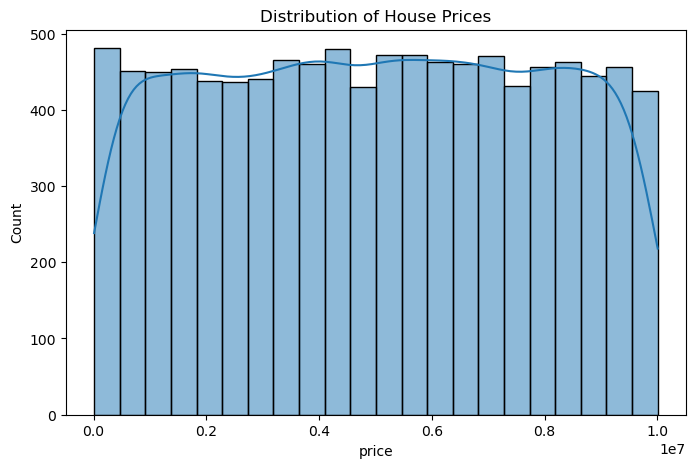

In [104]:
# Distribution of house prices
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

### 💰 Distribution of House Prices

The histogram shows that:

- The `price` variable is **almost uniformly distributed** across the range.
- There is **no clear skewness** or concentration around certain values.
- This again suggests that the dataset may be **synthetic**, as real housing prices usually follow a **right-skewed distribution** (many affordable houses and fewer very expensive ones).

💡 *Despite this, the uniform spread is useful for practicing regression since it covers a wide range of price values.*


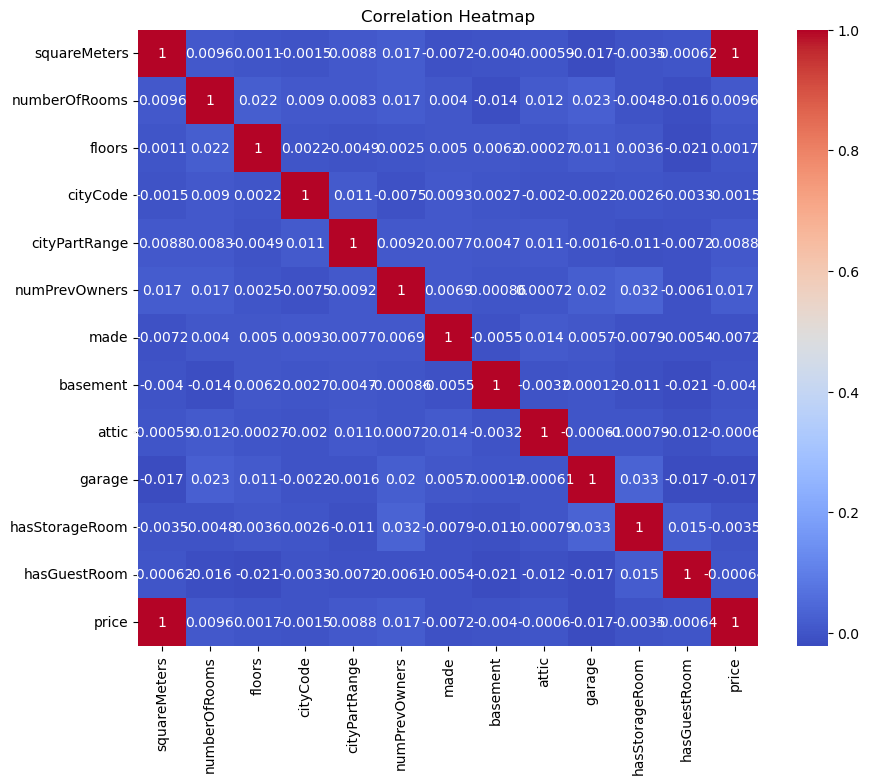

In [105]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### 🔥 Correlation Heatmap Analysis

From the correlation heatmap, we can observe that:

- Most features have **very low correlation values** with each other and with the target variable (`price`).
- The correlation between `price` and numerical features such as `squareMeters`, `numberOfRooms`, and `floors` is almost **zero**, which is unexpected and may indicate that the dataset values were **synthetically generated** or **randomized**.
- The absence of strong correlations (no values close to +1 or -1) means that **no single feature linearly explains price variations**.
- However, we will still apply **Linear Regression** as requested, to test how well it can fit the data and to analyze feature coefficients later.

💡 *In a real-world dataset, we would expect stronger positive correlations between features like house size or number of rooms and price.*


## 🧹 Data Cleaning and Feature Engineering

Before training our linear regression model, we need to:
1. Ensure all columns are numeric (convert Yes/No values to 1/0).
2. Verify there are no missing values or incorrect data types.
3. Separate the target variable (`price`) from the input features.
4. Optionally scale features if needed.


In [106]:
# Check for missing values
df.isnull().sum()

squareMeters         0
numberOfRooms        0
hasYard              0
hasPool              0
floors               0
cityCode             0
cityPartRange        0
numPrevOwners        0
made                 0
isNewBuilt           0
hasStormProtector    0
basement             0
attic                0
garage               0
hasStorageRoom       0
hasGuestRoom         0
price                0
dtype: int64

### Observations:
- The Dataset doesn't contain any missing value

In [107]:
# Check for duplicated values
df[df.duplicated()]

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price


### Observations:
- The Dataset doesn't contain any duplicated row

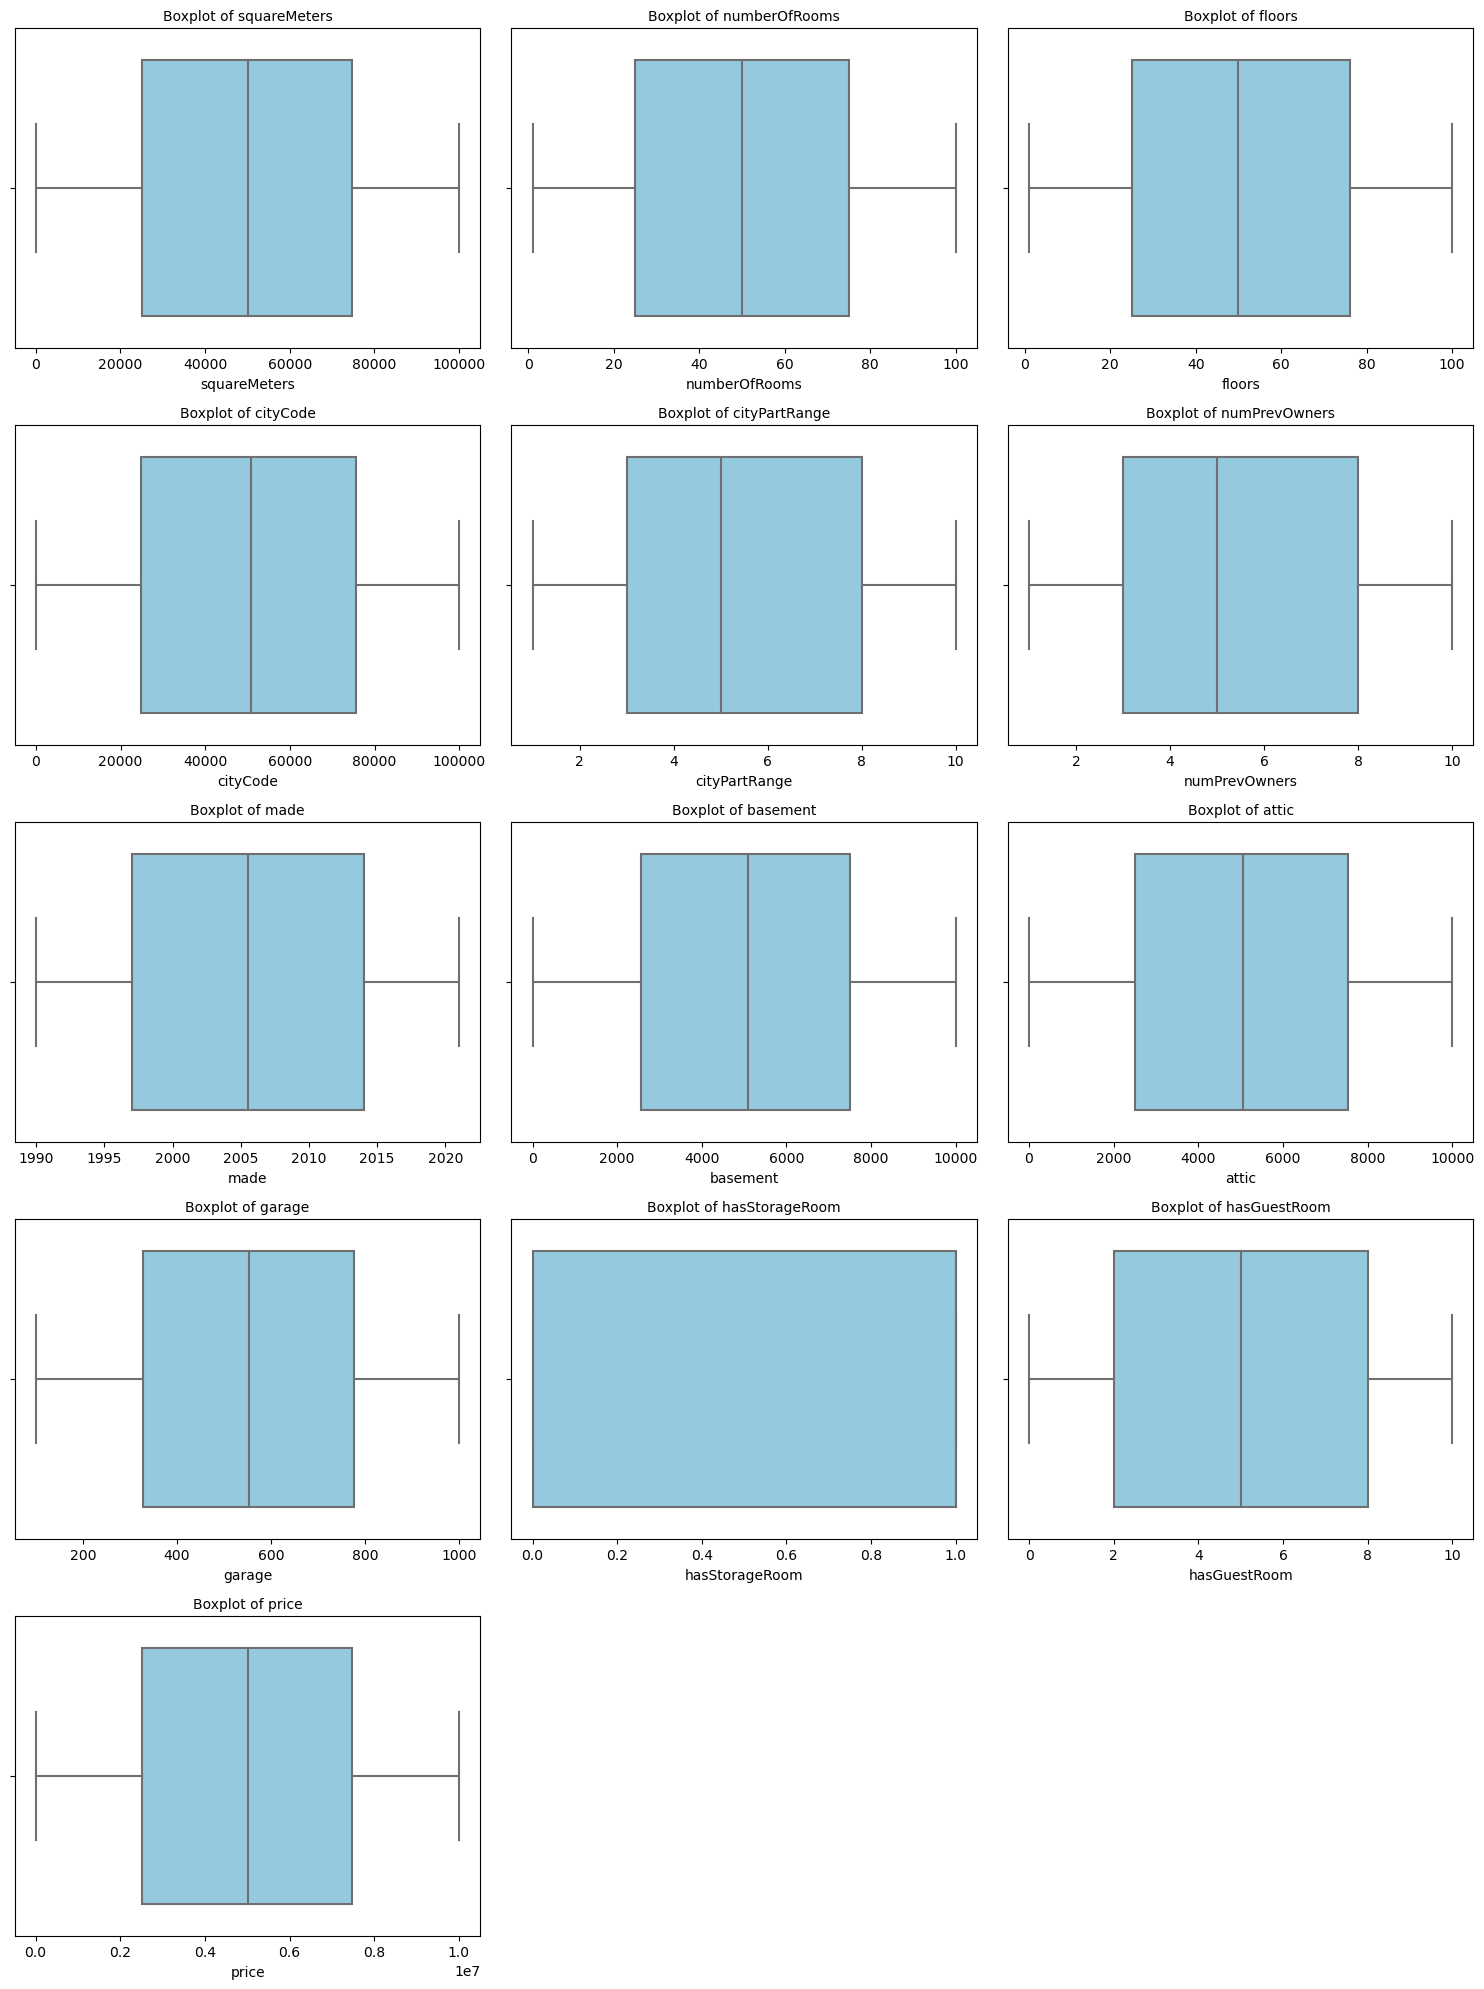

In [108]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate number of rows and columns dynamically
num_cols = len(numerical_cols)
cols = 3  # You can change this to 4 if you want wider plots
rows = math.ceil(num_cols / cols)

# Plot boxplots
plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=10)
plt.tight_layout()
plt.show()

### Observations:
- The Dataset doesn't any outliers

#### We start by converting boolean columns to numerical

In [109]:
# List of boolean columns
bool_cols = ['hasYard', 'hasPool', 'isNewBuilt', 'hasStormProtector']

# Display unique values for each boolean column
for col in bool_cols:
    print(f"{col}: {df[col].unique()}")


hasYard: ['No' 'Yes']
hasPool: ['Yes' 'No']
isNewBuilt: ['No' 'Yes']
hasStormProtector: ['Yes' 'No']


In [110]:
# Convert Yes/No columns to 1/0
binary_cols = ['hasYard', 'hasPool', 'isNewBuilt', 'hasStormProtector']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
    
# Check if well converted

df.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0


In [111]:
df.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0


### Age column
To improve our model, we create a new feature called houseAge to represent the age of the house. The year the house was built (made) is converted into the number of years since construction. Older houses may have different prices compared to newer ones, so this feature can help the model capture this effect.

The formula used is:

houseAge = Current Year − Year Built


After creating this column, the original made column is dropped since it is now represented in a more meaningful numeric form.

In [112]:
from datetime import datetime

# --- 1) Current year programmatically ---
current_year = datetime.now().year

# --- 2) Create houseAge (if 'made' exists) ---
if "made" in df.columns:
    df["houseAge"] = current_year - df["made"]

# Check the first few rows to verify
print(df[['houseAge']].head())



   houseAge
0        21
1        11
2         5
3        14
4        36


In [113]:
# --- 4) Drop 'made' (recommended after creating houseAge) ---
if "made" in df.columns:
    df.drop(columns=["made"], inplace=True)

In [114]:
df

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price,houseAge
0,75523,3,0,1,63,9373,3,8,0,1,4313,9005,956,0,7,7559081.5,21
1,80771,39,1,1,98,39381,8,6,1,0,3653,2436,128,1,2,8085989.5,11
2,55712,58,0,1,19,34457,6,8,0,0,2937,8852,135,1,9,5574642.1,5
3,32316,47,0,0,6,27939,10,4,0,1,659,7141,359,0,3,3232561.2,14
4,70429,19,1,1,90,38045,3,7,1,0,8435,2429,292,1,4,7055052.0,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1726,89,0,1,5,73133,7,6,0,1,9311,1698,218,0,4,176425.9,17
9996,44403,29,1,1,12,34606,9,4,0,1,9061,1742,230,0,0,4448474.0,36
9997,83841,3,0,0,69,80933,10,10,1,1,8304,7730,345,1,9,8390030.5,21
9998,59036,70,0,0,96,55856,1,3,0,1,2590,6174,339,1,4,5905107.0,16


## Apply Linear Regression model

#### Test Performance for different Train/Test splits

In [115]:
# Separate features and target
X = df.drop(columns=["price"])
y = df["price"]

# Split first (prevents leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## ⚙️ Handling Different Feature Scales

During the data exploration, we observed that some numerical features such as **`basement`**, **`attic`**, and **`garage`** have value ranges that differ significantly from **`squareMeters`**.  
Since **Linear Regression** is sensitive to the scale of features, variables with larger numeric ranges can dominate the model and affect coefficient interpretation.

To ensure that all features contribute equally, we apply **feature scaling** to normalize their values.  
This helps the model perform better and makes coefficients more comparable.

We can handle scale differences using one of the following techniques:

- **Standardization (Z-score scaling)**: transforms each feature to have a mean of 0 and a standard deviation of 1.  
- **Min-Max Scaling**: rescales all features to a fixed range, typically [0, 1].

In this project, we apply scaling to all numerical columns **before training the Linear Regression model**.


In [116]:
# Fit scaler ONLY on X_train, then transform both
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [117]:
# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [118]:
# Predict and evaluate
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Hold-out Test Results (20%) ===")
print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")

=== Hold-out Test Results (20%) ===
RMSE: 1922.423
MAE : 1510.034
R²  : 1.000


In [119]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

# Top 3 positive
top_positive = coefficients.sort_values(by='Coefficient', ascending=False).head(3)
print("\nTop 3 positive influential factors:")
print(top_positive)

# Top 3 negative
top_negative = coefficients.sort_values(by='Coefficient').head(3)
print("\nTop 3 negative influential factors:")
print(top_negative)


Top 3 positive influential factors:
        Feature   Coefficient
0  squareMeters  9.986308e+06
4        floors  5.392063e+03
2       hasYard  2.993859e+03

Top 3 negative influential factors:
     Feature  Coefficient
5   cityCode   -95.986904
10  basement   -81.870813
11     attic   -75.811869
